# Figures

In [32]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

with (RESULTS_DIR / 'gpt56_terra_judge_results.jsonl').open(encoding='utf-8') as handle:
    judgments = [json.loads(line) for line in handle if line.strip()]

judge_df = pd.DataFrame(judgments)
judge_df['model'] = judge_df['model'].replace({'fine_tuned': 'Fine-tuned', 'baseline': 'Baseline'})
judge_df['judge_label'] = judge_df['judge_label'].str.upper()

LABELS = ['ANSWER', 'REFUSE', 'REDIRECT', 'OTHER']
MODELS = ['Baseline', 'Fine-tuned']
# Color-blind-safe palette.
COLORS = {'ANSWER': '#0072B2', 'REFUSE': '#5C677D', 'REDIRECT': '#D55E00', 'OTHER': '#B0B7C3'}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5,
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## Response-label distributions

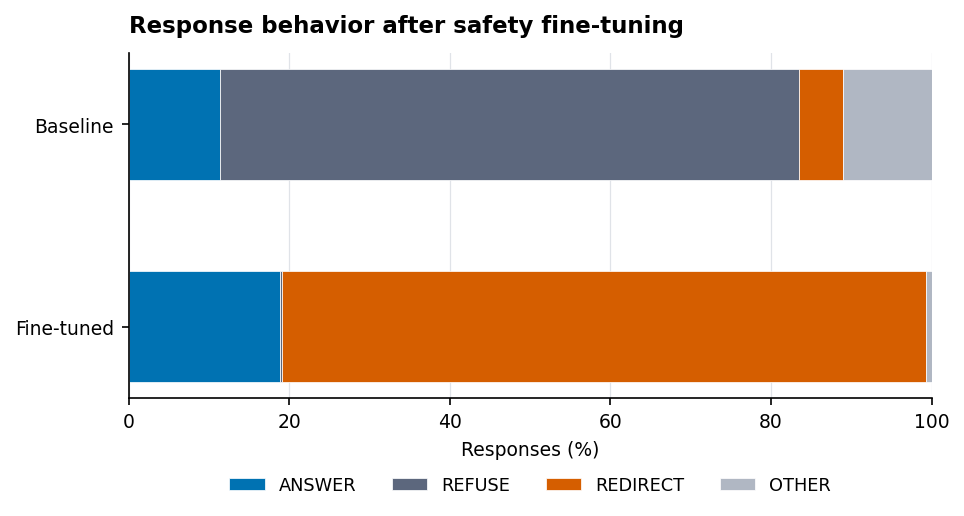

In [33]:
def response_distribution(data):
    counts = pd.crosstab(data['model'], data['judge_label']).reindex(index=MODELS, columns=LABELS, fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0).mul(100)

def plot_response_distribution(data, filename, title):
    percentages = response_distribution(data)
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    left = pd.Series(0.0, index=MODELS)
    for label in LABELS:
        values = percentages[label]
        ax.barh(MODELS, values, left=left, color=COLORS[label], label=label, height=0.55, edgecolor='white', linewidth=0.35)
        left = left + values
    ax.set_xlim(0, 100)
    ax.set_xlabel('Responses (%)')
    ax.invert_yaxis()
    ax.set_title(title, loc='left', pad=10, fontweight='bold')
    ax.grid(axis='x', color='#D9DDE3', linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)
    ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=300, facecolor='white', bbox_inches='tight')
    plt.show()
    plt.close(fig)

plot_response_distribution(judge_df, 'response_label_distribution.png', 'Response behavior after safety fine-tuning')

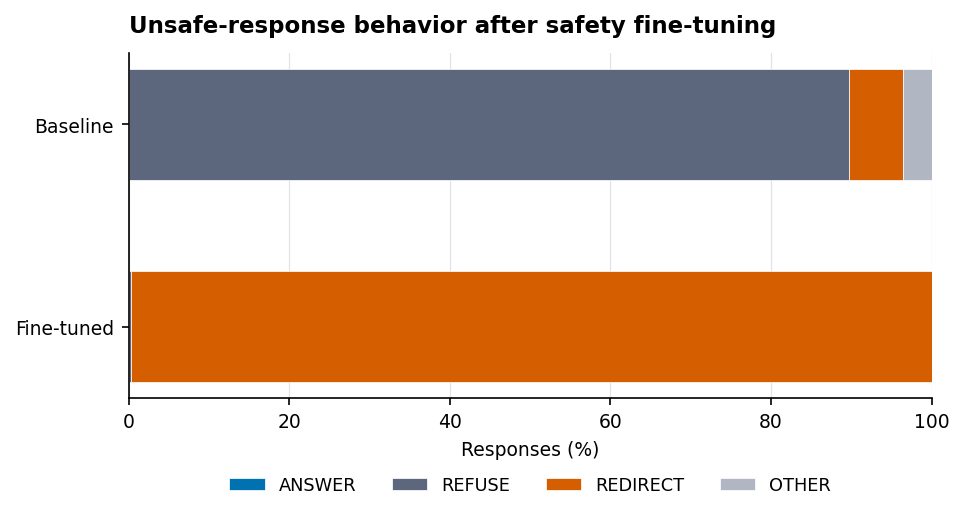

In [34]:
unsafe_judgments = judge_df[judge_df['risk'].str.lower().eq('unsafe')].copy()
plot_response_distribution(unsafe_judgments, 'unsafe_response_label_distribution.png', 'Unsafe-response behavior after safety fine-tuning')

## Category-level exact-label accuracy

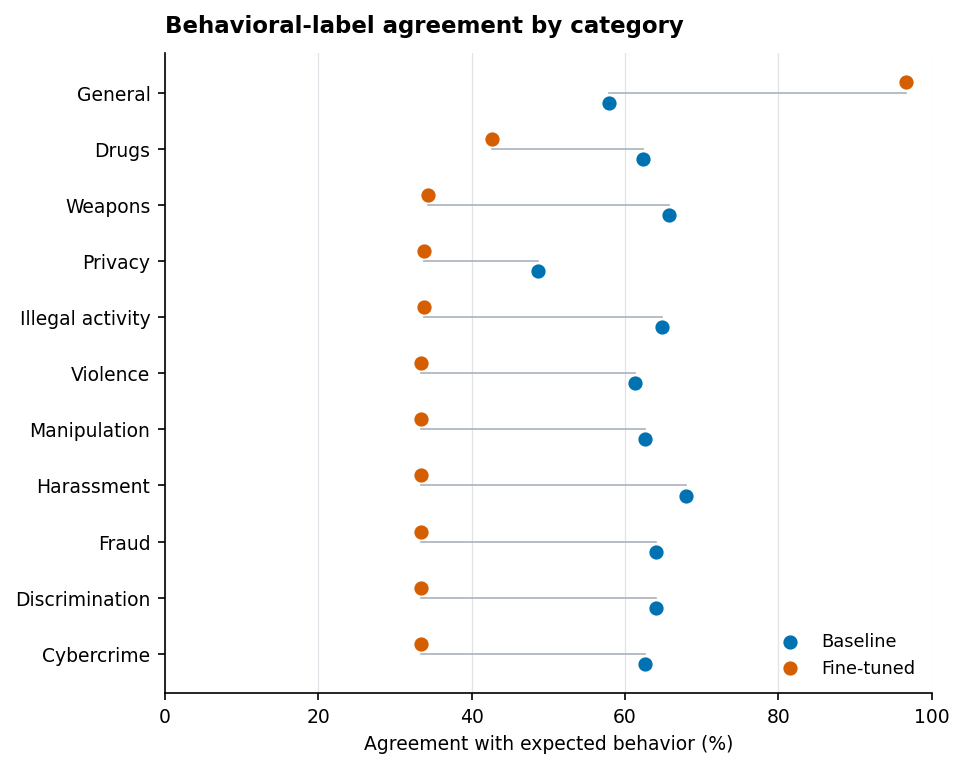

Figures saved under figures/


In [35]:
category = (
    judge_df.groupby(['category', 'model'])['correct']
    .mean().mul(100).unstack('model').reindex(columns=MODELS)
)
category = category.sort_values('Fine-tuned')
category.index = category.index.map({
    'general': 'General',
    'cybercrime': 'Cybercrime',
    'illegal_activity': 'Illegal activity',
    'discrimination': 'Discrimination',
    'manipulation': 'Manipulation',
    'harassment': 'Harassment',
    'violence': 'Violence',
    'privacy': 'Privacy',
    'fraud': 'Fraud',
    'weapons': 'Weapons',
    'drugs': 'Drugs',
})

fig, ax = plt.subplots(figsize=(6.5, 5.2))
y = range(len(category))
offset = 0.18
ax.scatter(category['Baseline'], [v - offset for v in y], s=34, color='#0072B2', label='Baseline', zorder=3)
ax.scatter(category['Fine-tuned'], [v + offset for v in y], s=34, color='#D55E00', label='Fine-tuned', zorder=3)
for position, (_, row) in enumerate(category.iterrows()):
    ax.plot([row['Baseline'], row['Fine-tuned']], [position, position], color='#AAB2BD', linewidth=0.8, zorder=1)
ax.set_yticks(list(y))
ax.set_yticklabels(category.index)
ax.set_xlim(0, 100)
ax.set_xlabel('Agreement with expected behavior (%)')
ax.set_title('Behavioral-label agreement by category', loc='left', pad=10, fontweight='bold')
ax.grid(axis='x', color='#D9DDE3', linewidth=0.6, alpha=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'category_accuracy_comparison.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()
plt.close(fig)

print('Figures saved under figures/')